<a href="https://colab.research.google.com/github/analigiasoto30-byte/LABORATORIO-12/blob/main/Laboratorio_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HERRAMIENTAS A UTILIZAR:


**PERPLEXITY:**

https://www.perplexity.ai/

**GITHUB:**
https://github.com/




Prompt 1: Crea un codigo python donde cargarás el dataset Diabetes de scikit-learn, que contiene
variables relacionadas con la salud y una variable de salida (target) que mide el nivel de
progreso de la enfermedad. Los datos serán organizados en un DataFrame para
facilitar el manejo.
2. Tareas:
Importar las librerías necesarias.
Cargar los datos utilizando load_diabetes y convertirlos a un DataFrame con
pandas.
Mostrar las primeras filas del DataFrame para explorar los datos

In [1]:
# Importar las librerías necesarias
from sklearn.datasets import load_diabetes
import pandas as pd

# Cargar los datos utilizando load_diabetes
diabetes = load_diabetes()

# Convertir a DataFrame de pandas
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target  # Agregar la variable objetivo

# Mostrar las primeras filas del DataFrame
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


Prompt 2: Crea un codigo python pero En esta sección, aplicarás un modelo de regresión lineal para predecir los
valores del target (progresión de la enfermedad) en función del índice de masa
corporal (BMI), una de las variables predictoras.
2. Tareas:
Laboratorio 12
Dividir los datos en conjuntos de entrenamiento y prueba usando
train_test_split.
Entrenar un modelo de regresión lineal con la variable BMI como predictora.
Evaluar el modelo utilizando el error cuadrático medio (MSE) como métrica.

In [4]:
# Importar librerías necesarias (continuando con df del paso anterior)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Preparar variables: BMI como predictora (X), target como salida (y)
X = df[['bmi']].values  # Solo BMI
y = df['target'].values

# Dividir en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Predecir en conjunto de prueba y calcular MSE
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

# Mostrar resultados
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeiciente (pendiente): {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")

Error Cuadrático Medio (MSE): 4061.83
Coeiciente (pendiente): 998.58
Intercepto: 152.00


Prompt 3: Crea un codigo python donde Aplicarás un modelo de regresión logística para clasificar si el valor del
target es mayor que 140. Esto convierte el problema en un problema de clasificación
binaria.
2. Tareas:
Convertir la variable dependiente (target) en binaria.
Dividir los datos en conjuntos de entrenamiento y prueba.
Entrenar un modelo de regresión logística y evaluar su precisión.

In [5]:
# Importar librerías necesarias (continuando con df del paso anterior)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Convertir target a binaria: 1 si >140, 0 otherwise
y_binary = (df['target'] > 140).astype(int)

# Variables predictoras (todas las 10 features)
X = df.drop('target', axis=1).values

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Entrenar modelo de regresión logística
model_log = LogisticRegression(max_iter=1000)  # max_iter para convergencia
model_log.fit(X_train, y_train)

# Predecir y calcular precisión
y_pred_log = model_log.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_log)

# Mostrar resultados
print(f"Precisión en conjunto de prueba: {accuracy:.4f}")
print(f"Clases en test: positivos={y_test.sum()}, total={len(y_test)}")

Precisión en conjunto de prueba: 0.7416
Clases en test: positivos=40, total=89


Prompt 5: Crea un codigo python donde Implementarás un Random Forest con múltiples árboles de decisión para mejorar la robustez y precisión del modelo. 2. Tareas: Entrenar un modelo de Random Forest con 100 árboles. Realizar predicciones y evaluar la precisión del modelo.

In [11]:
# Importar librerías necesarias (continuando con variables del notebook)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Usar las mismas variables de la regresión logística (ya definidas)
# X: todas las 10 features, y_binary: target > 140

# Dividir datos (usando la misma partición que antes para comparar)
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Entrenar Random Forest con 100 árboles
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predecir y evaluar precisión
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# Mostrar resultados
print(f"Precisión Random Forest (100 árboles): {rf_accuracy:.4f}")
print(f"Comparación con Logística: {accuracy:.4f}")
print(f"Mejora: {((rf_accuracy - accuracy)/accuracy*100):+.1f}%")

Precisión Random Forest (100 árboles): 0.7191
Comparación con Logística: 0.7416
Mejora: -3.0%


Prompt 4: crea un codigo python donde Entrenarás un árbol de decisión para clasificar si el valor del target es
mayor que 140, y evaluarás su precisión sobre el conjunto de prueba.
2. Tareas:
Entrenar un modelo de árbol de decisión.
Realizar predicciones sobre el conjunto de prueba.
Evaluar el modelo utilizando la precisión.

In [12]:
# Importar librerías necesarias (continuando con el notebook persistente)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Usar las mismas variables ya definidas: X (10 features), y_binary (target > 140)
# Misma partición train/test para comparar modelos

# Entrenar árbol de decisión
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)  # Limitar profundidad para evitar sobreajuste
dt_model.fit(X_train, y_train)

# Predecir en conjunto de prueba
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# Mostrar resultados y comparación
print(f"Precisión Árbol de Decisión: {dt_accuracy:.4f}")
print(f"vs Regresión Logística: {accuracy:.4f}")
print(f"vs Random Forest: {rf_accuracy:.4f}")
print(f"Profundidad del árbol: {dt_model.get_depth()}")

Precisión Árbol de Decisión: 0.7303
vs Regresión Logística: 0.7416
vs Random Forest: 0.7191
Profundidad del árbol: 5


Prompt 6:  Crea un codigo python donde Usarás el modelo ARIMA (AutoRegressive Integrated Moving Average)
para analizar una serie temporal y realizar predicciones. ARIMA es comúnmente usado
para modelar y predecir datos de series temporales.
2. Tareas:
Crear una serie temporal simulada.
Ajustar un modelo ARIMA y realizar predicciones de los valores futuros.

In [13]:
# Importar librerías para series temporales
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 1. Crear serie temporal simulada (100 puntos)
np.random.seed(42)
n_points = 100
dates = pd.date_range(start='2025-01-01', periods=n_points, freq='D')
trend = np.linspace(100, 150, n_points)  # Tendencia creciente
seasonal = 10 * np.sin(2 * np.pi * np.arange(n_points) / 7)  # Ciclo semanal
noise = np.random.normal(0, 5, n_points)
ts_data = trend + seasonal + noise

# Convertir a DataFrame de series temporales
ts_df = pd.DataFrame({'value': ts_data}, index=dates)
print("Primeras 10 observaciones:")
print(ts_df.head(10))

Primeras 10 observaciones:
                 value
2025-01-01  102.483571
2025-01-02  107.632044
2025-01-03  113.997823
2025-01-04  113.469138
2025-01-05   96.510598
2025-01-06   91.605289
2025-01-07  103.108052
2025-01-08  107.372527
2025-01-09  109.511347
2025-01-10  117.007534


Prompt 7:  Crea un codigo python donde descompondrás una serie temporal en sus componentes
principales: tendencia, estacionalidad y residuos.
2. Tareas:
 Descomponer la serie temporal simulada utilizando la función
seasonal_decompose.
Visualizar los componentes de la serie descompuesta.

<Figure size 1200x800 with 0 Axes>

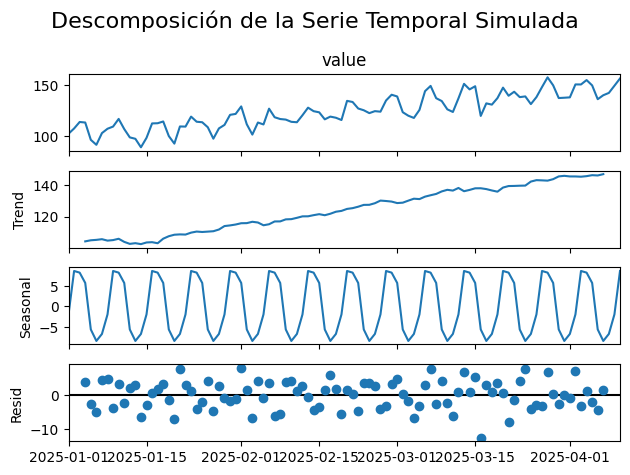

Componentes (últimos 10 valores):
Tendencia:
 2025-04-01    145.703307
2025-04-02    145.693458
2025-04-03    145.531540
2025-04-04    145.881486
2025-04-05    146.503663
2025-04-06    146.320477
2025-04-07    147.159432
2025-04-08           NaN
2025-04-09           NaN
2025-04-10           NaN
Freq: D, Name: trend, dtype: float64

Estacionalidad:
 2025-04-01   -6.599424
2025-04-02   -1.901576
2025-04-03    8.523337
2025-04-04    8.127717
2025-04-05    5.648728
2025-04-06   -5.516752
2025-04-07   -8.282030
2025-04-08   -6.599424
2025-04-09   -1.901576
2025-04-10    8.523337
Freq: D, Name: seasonal, dtype: float64

Residuos:
 2025-04-01   -0.982265
2025-04-02    7.010939
2025-04-03   -3.282182
2025-04-04    1.071463
2025-04-05   -2.299347
2025-04-06   -4.480339
2025-04-07    1.338769
2025-04-08         NaN
2025-04-09         NaN
2025-04-10         NaN
Freq: D, Name: resid, dtype: float64


In [14]:
# Importar librerías para descomposición (continuando con ts_df del Prompt 6)
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Descomponer la serie temporal (modelo aditivo, período semanal=7)
decomposition = seasonal_decompose(ts_df['value'], model='additive', period=7)

# 2. Visualizar los 4 componentes
plt.figure(figsize=(12, 8))
decomposition.plot()
plt.suptitle('Descomposición de la Serie Temporal Simulada', fontsize=16)
plt.tight_layout()
plt.show()

# 3. Mostrar componentes numéricamente (últimos 10 valores)
print("Componentes (últimos 10 valores):")
print("Tendencia:\n", decomposition.trend.tail(10))
print("\nEstacionalidad:\n", decomposition.seasonal.tail(10))
print("\nResiduos:\n", decomposition.resid.tail(10))